## Industial Filter Predictive Maintenance

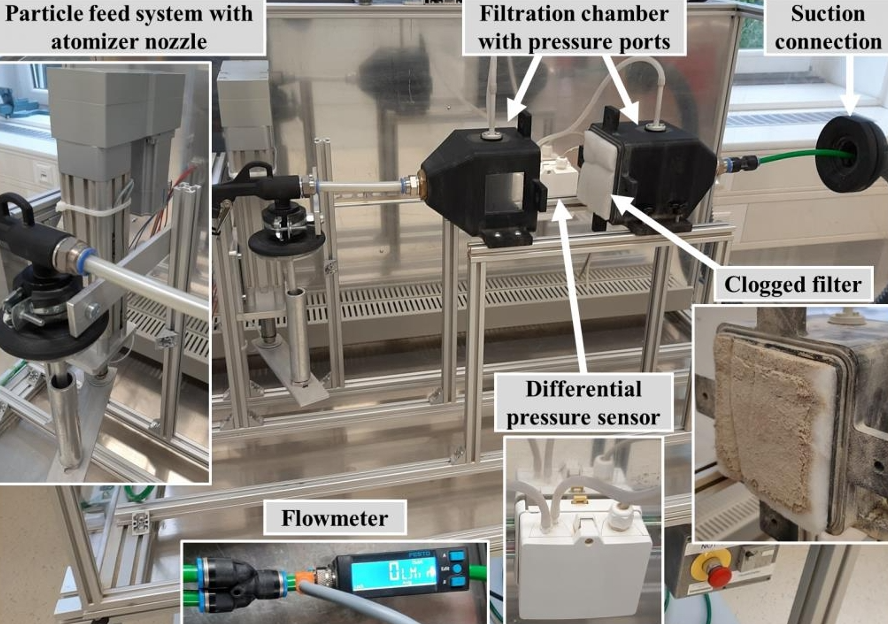

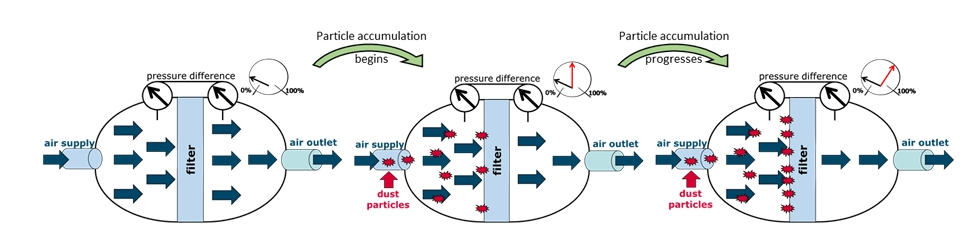

### 🎯 Objective

The goal of this project is to develop a predictive maintenance model that estimates the Remaining Useful Life (RUL) of industrial air filters using time-series sensor data.

Unlike traditional preventive maintenance strategies where filters are replaced at fixed intervals, this project aims to predict failure based on the actual condition of the filter. By leveraging machine learning techniques, the model will learn degradation patterns from historical data and provide accurate RUL predictions to support condition-based maintenance decisions.

### 📊 Dataset Description

This dataset represents the degradation process of industrial air filters subjected to dust loading over time. As dust accumulates, the filter gradually clogs, leading to an increase in differential pressure across the filter.

Each dataset consists of multiple life cycles (identified by `Data_No`), where each life cycle is a time-series recording of sensor measurements such as differential pressure, flow rate, dust type, and dust feed rate.

Key characteristics of the dataset:

- The primary degradation indicator is **differential pressure**, which increases as the filter clogs.
- A filter is considered to have failed when the differential pressure exceeds **600 Pa**.
- The training dataset is **right-censored**, meaning many filters are replaced before failure, and their true end-of-life is unknown.
- The test dataset includes **Remaining Useful Life (RUL)** values, which serve as ground truth for evaluation.

This setup reflects real-world industrial scenarios, where incomplete data and early replacements make predictive modeling more challenging.

### 💡 Why This Project Matters

Predictive maintenance helps reduce operational costs, minimize unexpected failures, and improve system reliability. By accurately estimating the remaining life of components, industries can move from time-based maintenance to condition-based maintenance, leading to more efficient and intelligent systems.

#### Importing Dependencies

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Data Loading and Understanding

In [3]:
train = pd.read_csv('Data/Train_data.csv')
test = pd.read_csv('Data/Test_data.csv')
train.head()

,Data_No,Differential_pressure,Flow_rate,Time,Dust_feed,Dust
0,1,0.0,0.0,0.1,236.428943,"ISO 12103-1, A3 Medium Test Dust"
1,1,0.0,0.0,0.2,236.428943,"ISO 12103-1, A3 Medium Test Dust"
2,1,0.0,0.0,0.3,236.428943,"ISO 12103-1, A3 Medium Test Dust"
3,1,0.0,0.0,0.4,236.428943,"ISO 12103-1, A3 Medium Test Dust"
4,1,0.0,0.0,0.5,236.428943,"ISO 12103-1, A3 Medium Test Dust"


#### Data Quality Checks and Initial Cleaning
Before exploratory analysis, the dataset is checked for missing values, duplicates, incorrect data types, and invalid measurements. Since this is a grouped time-series degradation dataset, cleaning must preserve lifecycle order and avoid removing valid early-stage observations.

In [4]:
# Checking for more information about the dataset
print(f' The dataset has {train.shape[0]} rows and {train.shape[1]} columns \n')
print("Train data info") # Checking for data types of the dataset
train.info()
print(f'\nMissing values in train data: {train.isnull().sum().sum()}') # Checking for missing values in the dataset
print(f'\nDuplicate values in train data: {train.duplicated().sum()} \n') # Checking for duplicate values in the dataset
print('Statistical summary of train data') # Checking the statistical summary of the dataset
train.describe(include='all')

 The dataset has 39420 rows and 6 columns 

Train data info
<class 'pandas.DataFrame'>
RangeIndex: 39420 entries, 0 to 39419
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Data_No                39420 non-null  int64  
 1   Differential_pressure  39420 non-null  float64
 2   Flow_rate              39420 non-null  float64
 3   Time                   39420 non-null  float64
 4   Dust_feed              39420 non-null  float64
 5   Dust                   39420 non-null  str    
dtypes: float64(4), int64(1), str(1)
memory usage: 1.8 MB

Missing values in train data: 0

Duplicate values in train data: 0 

Statistical summary of train data


,Data_No,Differential_pressure,Flow_rate,Time,Dust_feed,Dust
count,39420.000000,39420.000000,39420.000000,39420.000000,39420.000000,39420
unique,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,"ISO 12103-1, A3 Medium Test Dust"
freq,NaN,NaN,NaN,NaN,NaN,18929
mean,25.167453,78.232050,66.095780,49.135490,132.247854,NaN
std,14.315149,107.342894,11.306582,39.088269,62.716754,NaN
min,1.000000,0.000000,0.000000,0.100000,59.107236,NaN
25%,12.000000,8.590133,58.458498,19.800000,79.246266,NaN
50%,24.000000,35.174340,59.040107,39.900000,118.214472,NaN
75%,38.000000,102.358200,81.136739,65.800000,158.492533,NaN


In [5]:
# Checking if time is ordered per lifecycle
train = train.sort_values(['Data_No', 'Time'])

# Confirming lifecycle structure
print('Number of lifecycle:' , train['Data_No'].nunique())
train.groupby('Data_No').size()

Number of lifecycle: 50


Data_No
1      449
2      449
3      449
4      897
5      897
6      897
7     1794
8     1794
9      669
10     669
11     623
12     669
13     669
14     669
15     669
16     669
17     669
18     669
19     669
20    1338
21    1338
22     669
23     897
24     897
25     335
26     335
27     446
28     598
29     446
30     446
31    1794
32    1338
33     897
34     669
35     669
36     669
37     446
38     598
39     449
40     335
41    1794
42    1338
43    1022
44     656
45     897
46     626
47    1046
48     449
49     446
50     598
dtype: int64

#### Exploratory Data Analysis (EDA)

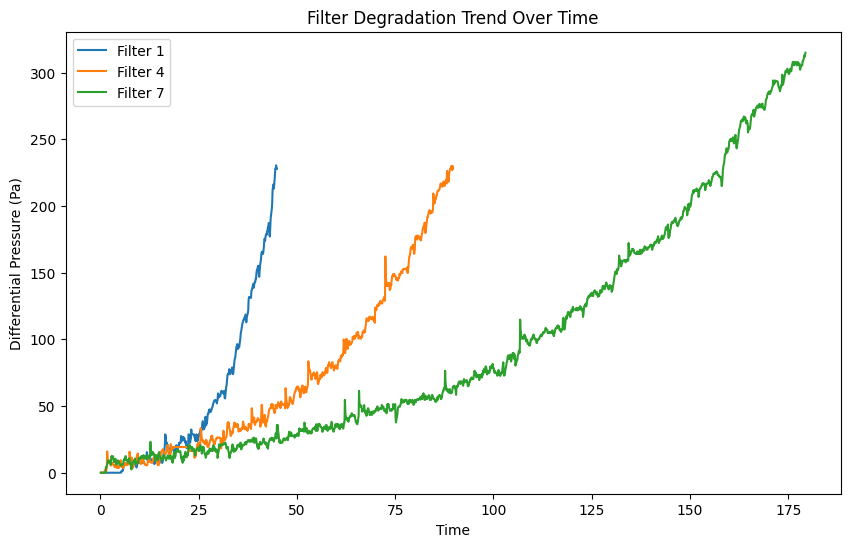

In [6]:
# Degradation trend over time
# Select a few filters (lifecycle) to visualize
sample_ids = [1, 4, 7]
plt.figure(figsize=(10, 6))
for i in sample_ids:
    subset = train[train['Data_No'] == i]
    plt.plot(subset['Time'], subset['Differential_pressure'], label=f'Filter {i}')

plt.xlabel('Time')
plt.ylabel('Differential Pressure (Pa)')
plt.title('Filter Degradation Trend Over Time')
plt.legend()
plt.show()

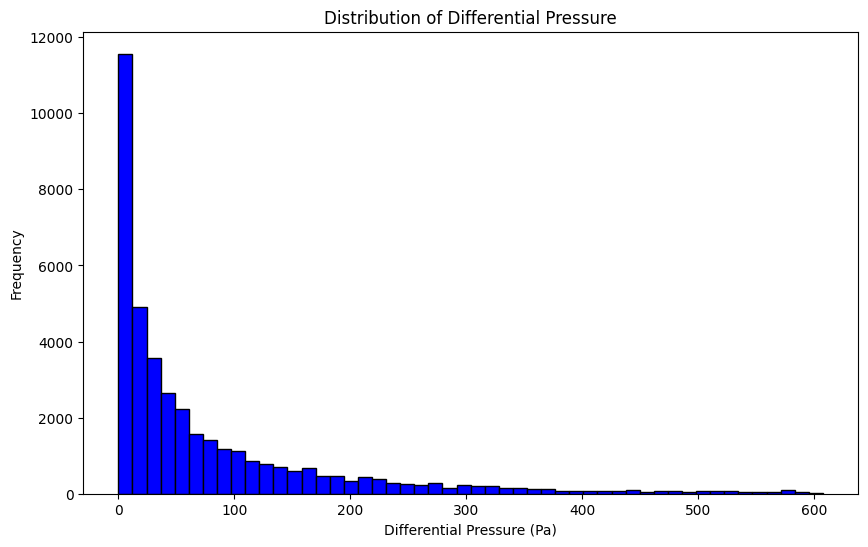

In [7]:
# Distribution of differential pressure
plt.figure(figsize=(10, 6))
plt.hist(train['Differential_pressure'], bins=50, color='blue', edgecolor='black')
plt.xlabel('Differential Pressure (Pa)')
plt.ylabel('Frequency')
plt.title('Distribution of Differential Pressure')
plt.show()

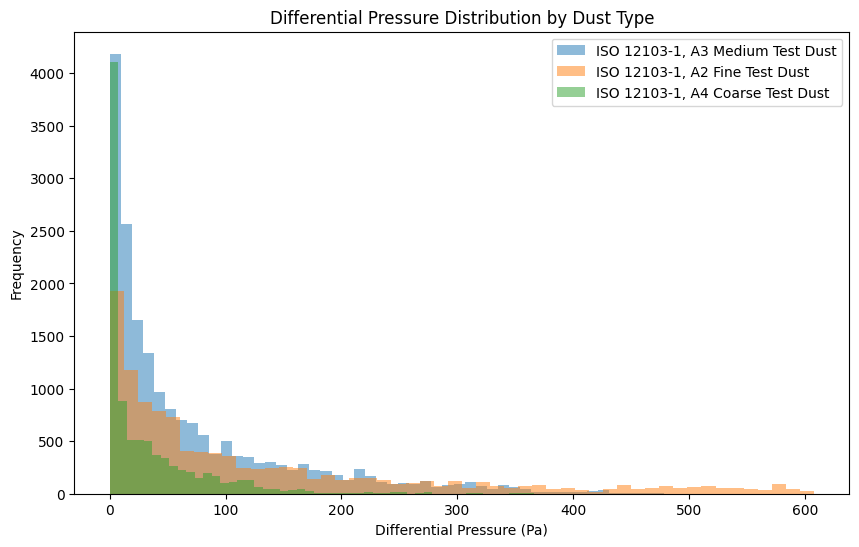

In [8]:
# Effect of dust type on degradation

plt.figure(figsize=(10, 6))

for dust_type in train["Dust"].unique():
    subset = train[train["Dust"] == dust_type]
    
    plt.hist(subset["Differential_pressure"], bins=50, alpha=0.5, label=dust_type)

plt.xlabel("Differential Pressure (Pa)")
plt.ylabel("Frequency")
plt.title("Differential Pressure Distribution by Dust Type")
plt.legend()

plt.show()

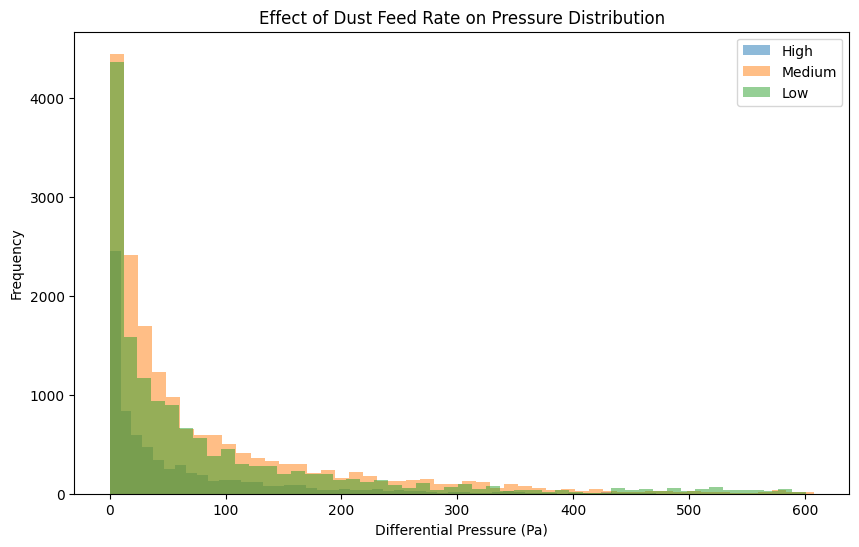

In [9]:
# Effect of dust feed rate on degradation

plt.figure(figsize=(10, 6))

# Create 3 groups: low, medium, high dust feed
train["Dust_feed_group"] = pd.qcut(train["Dust_feed"], q=3, labels=["Low", "Medium", "High"])

for group in train["Dust_feed_group"].unique():
    subset = train[train["Dust_feed_group"] == group]
    
    plt.hist(subset["Differential_pressure"], bins=50, alpha=0.5, label=group)

plt.xlabel("Differential Pressure (Pa)")
plt.ylabel("Frequency")
plt.title("Effect of Dust Feed Rate on Pressure Distribution")
plt.legend()

plt.show()

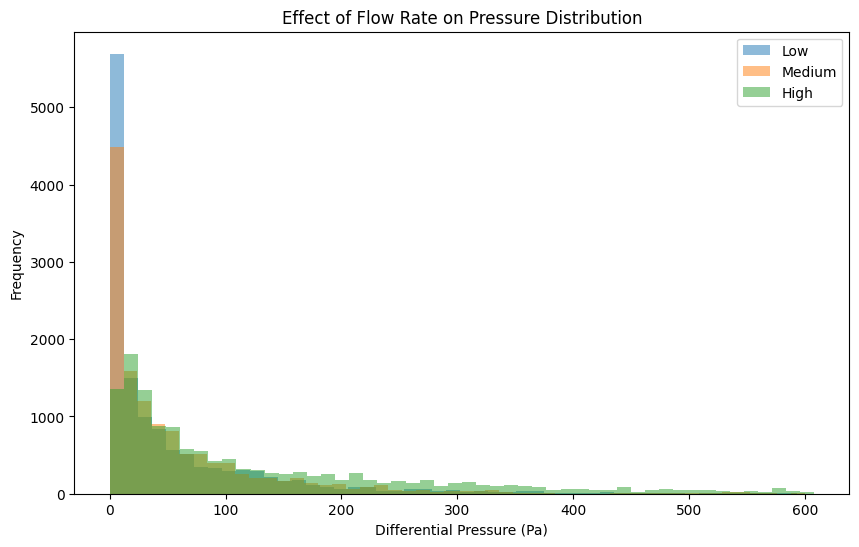

In [10]:
# Effect of flow rate on degradation
plt.figure(figsize=(10, 6))

# Create groups for flow rate
train["Flow_group"] = pd.qcut(train["Flow_rate"], q=3, labels=["Low", "Medium", "High"])

for group in train["Flow_group"].unique():
    subset = train[train["Flow_group"] == group]
    
    plt.hist(subset["Differential_pressure"], bins=50, alpha=0.5, label=group)

plt.xlabel("Differential Pressure (Pa)")
plt.ylabel("Frequency")
plt.title("Effect of Flow Rate on Pressure Distribution")
plt.legend()

plt.show()

### 📊 Key Insights from Exploratory Data Analysis (EDA)

The exploratory data analysis provided several important insights into the degradation behavior of industrial filters:

1. **Progressive and Non-Linear Degradation**  
   Differential pressure consistently increases over time, confirming it as a strong indicator of filter degradation. The increase is non-linear, with degradation accelerating as the filter approaches failure.

2. **Variability Across Lifecycles**  
   Different filters exhibit varying degradation rates and lifespans, indicating the influence of operating conditions and system variability.

3. **Imbalanced Data Distribution**  
   The dataset is heavily skewed toward lower pressure values, with relatively few observations near the failure threshold (600 Pa). This reflects real-world scenarios where components are often replaced before failure.

4. **Strong Influence of Dust Type**  
   Dust type has a significant impact on degradation. Fine dust (A2) leads to higher pressure buildup and faster clogging, while coarse dust (A4) results in slower degradation. Medium dust (A3) shows intermediate behavior.

5. **Moderate Effect of Dust Feed Rate**  
   Higher dust feed rates generally lead to faster pressure increases, although the effect is less pronounced compared to dust type.

6. **Minimal Impact of Flow Rate**  
   Flow rate shows little influence on degradation patterns, likely due to controlled operating conditions within each lifecycle.

Overall, the analysis highlights that filter degradation is driven primarily by dust characteristics and loading conditions, with clear variability across different operating scenarios.

##### RUL (Remaining Useful Life) Target Creation

In [11]:
# Step 1: Get max time per lifecycle
max_time_per_cycle = train.groupby("Data_No")["Time"].max().reset_index()
max_time_per_cycle.columns = ["Data_No", "max_time"]

# Step 2: Merge back into dataset
train = train.merge(max_time_per_cycle, on="Data_No")

# Step 3: Create RUL
train["RUL"] = train["max_time"] - train["Time"]

In [12]:
train[['Data_No', 'Time', 'max_time', 'RUL']].head()

,Data_No,Time,max_time,RUL
0,1,0.1,44.9,44.8
1,1,0.2,44.9,44.7
2,1,0.3,44.9,44.6
3,1,0.4,44.9,44.5
4,1,0.5,44.9,44.4


##### Saving the Processed Data

In [13]:
# Save the updated dataset with RUL
train.to_csv('Data/train_with_rul.csv', index=False)